In [1]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
        

In [2]:
#fewrel_t5 results-si
experiments = {'run_1':'/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_1_forgetting_matrix.json',
               'run_2': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_2_forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_3_forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_4_forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/si/model_5_forgetting_matrix.json'}

In [3]:
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])

In [4]:
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)


In [5]:
combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')


In [6]:
accuracy_matrix

task,1,2,3,4,5,6,7,8
base_task,,,,,,,,
1,0.977571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.945429,0.850000,NaN,NaN,NaN,NaN,NaN,NaN
3,0.949143,0.804429,0.860286,NaN,NaN,NaN,NaN,NaN
4,0.946429,0.787429,0.849143,0.880143,NaN,NaN,NaN,NaN
5,0.952714,0.777857,0.832714,0.852143,0.858429,NaN,NaN,NaN
6,0.948000,0.781714,0.829000,0.863000,0.838000,0.899000,NaN,NaN
7,0.955429,0.781286,0.825143,0.861143,0.829714,0.878714,0.883857,NaN
8,0.951429,0.774429,0.816000,0.845571,0.821000,0.869286,0.888286,0.878286


In [6]:
accuracy_matrix.to_json('fewre_t5_accuracy_matrix.json', orient='split', indent=4, )


<Figure size 1000x800 with 0 Axes>

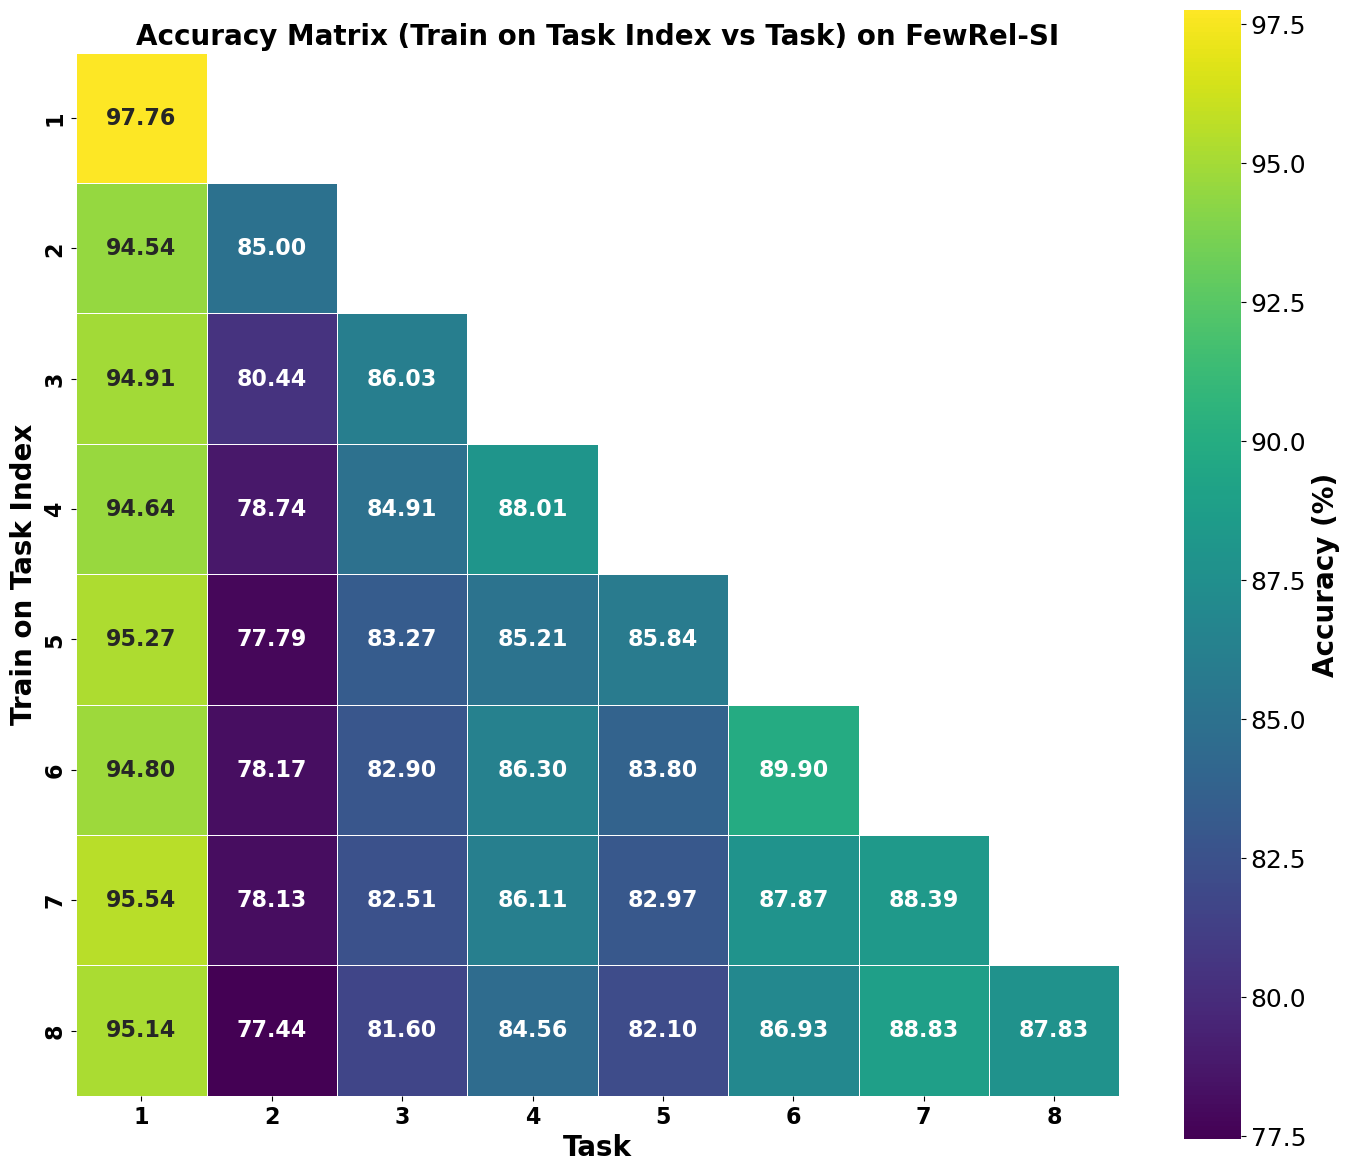

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)
df_percent = df * 100  # Convert to percentage
# Update the y-axis label
plt.figure(figsize=(10, 8))
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    df_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 16, "weight": "bold"},
    linewidths=0.5,
    square=True
)

plt.title("Accuracy Matrix (Train on Task Index vs Task) on FewRel-SI", fontsize=20, weight="bold")
plt.xlabel("Task", fontsize=20, weight="bold")
plt.ylabel("Train on Task Index", fontsize=20, weight="bold")
plt.xticks(fontsize=16, weight="bold")
plt.yticks(fontsize=16, weight="bold")

# Adjust colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Accuracy (%)", fontsize=20, weight="bold")
plt.tight_layout()
file_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_si_fewrel.png"
eps_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_si_fewrel.eps"
plt.savefig(file_path, dpi=350)
plt.savefig(eps_path, format='eps')
# plt.close()
plt.show()


In [8]:
#tacred_t5 results-ewc

experiments = {'run_1':'/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_1_forgetting_matrix.json',
               'run_2': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_2_forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_3_forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_4_forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/ewc/model_5_forgetting_matrix.json'}

In [9]:
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])

In [10]:
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)


In [11]:
combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')


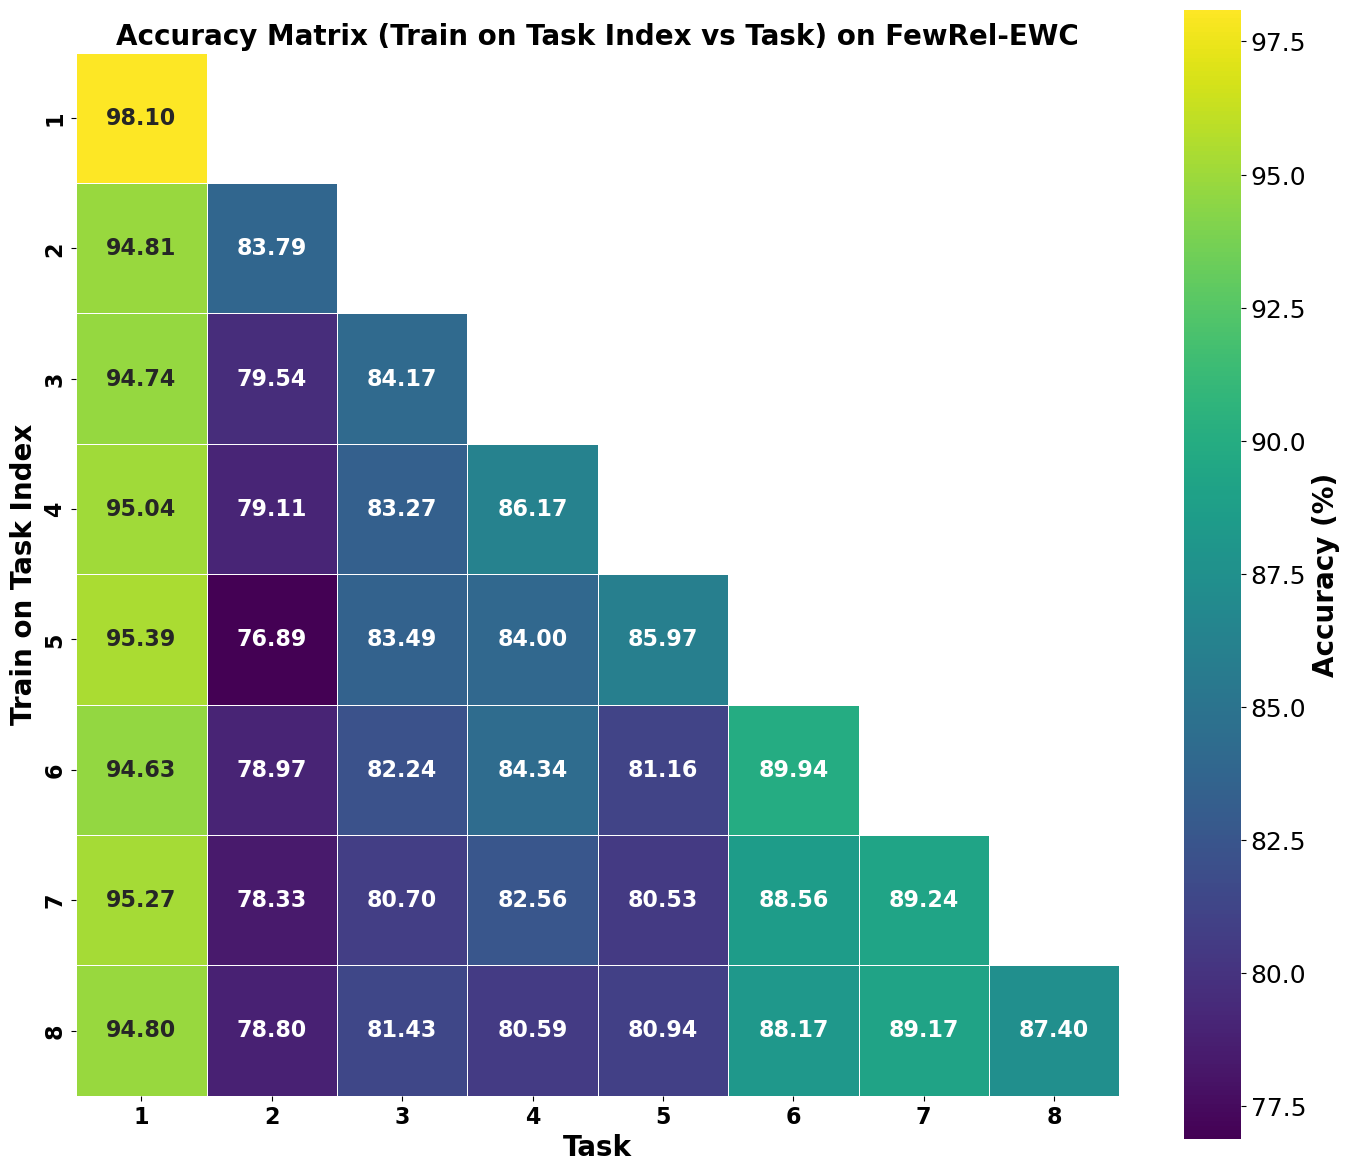

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)

df_percent = df * 100  # Convert to percentage
# Update the y-axis label
# Save the heatmap with updated font sizes as a high-resolution PNG
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    df_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 16, "weight": "bold"},
    linewidths=0.5,
    square=True
)

plt.title("Accuracy Matrix (Train on Task Index vs Task) on FewRel-EWC", fontsize=20, weight="bold")
plt.xlabel("Task", fontsize=20, weight="bold")
plt.ylabel("Train on Task Index", fontsize=20, weight="bold")
plt.xticks(fontsize=16, weight="bold")
plt.yticks(fontsize=16, weight="bold")

# Adjust colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Accuracy (%)", fontsize=20, weight="bold")

# Save the figure
file_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_ewc_fewrel.png"
eps_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_ewc_fewrel.eps"
plt.tight_layout()
plt.savefig(file_path, dpi=350)
# plt.savefig(eps_path, format='eps')
# plt.close()
plt.show()






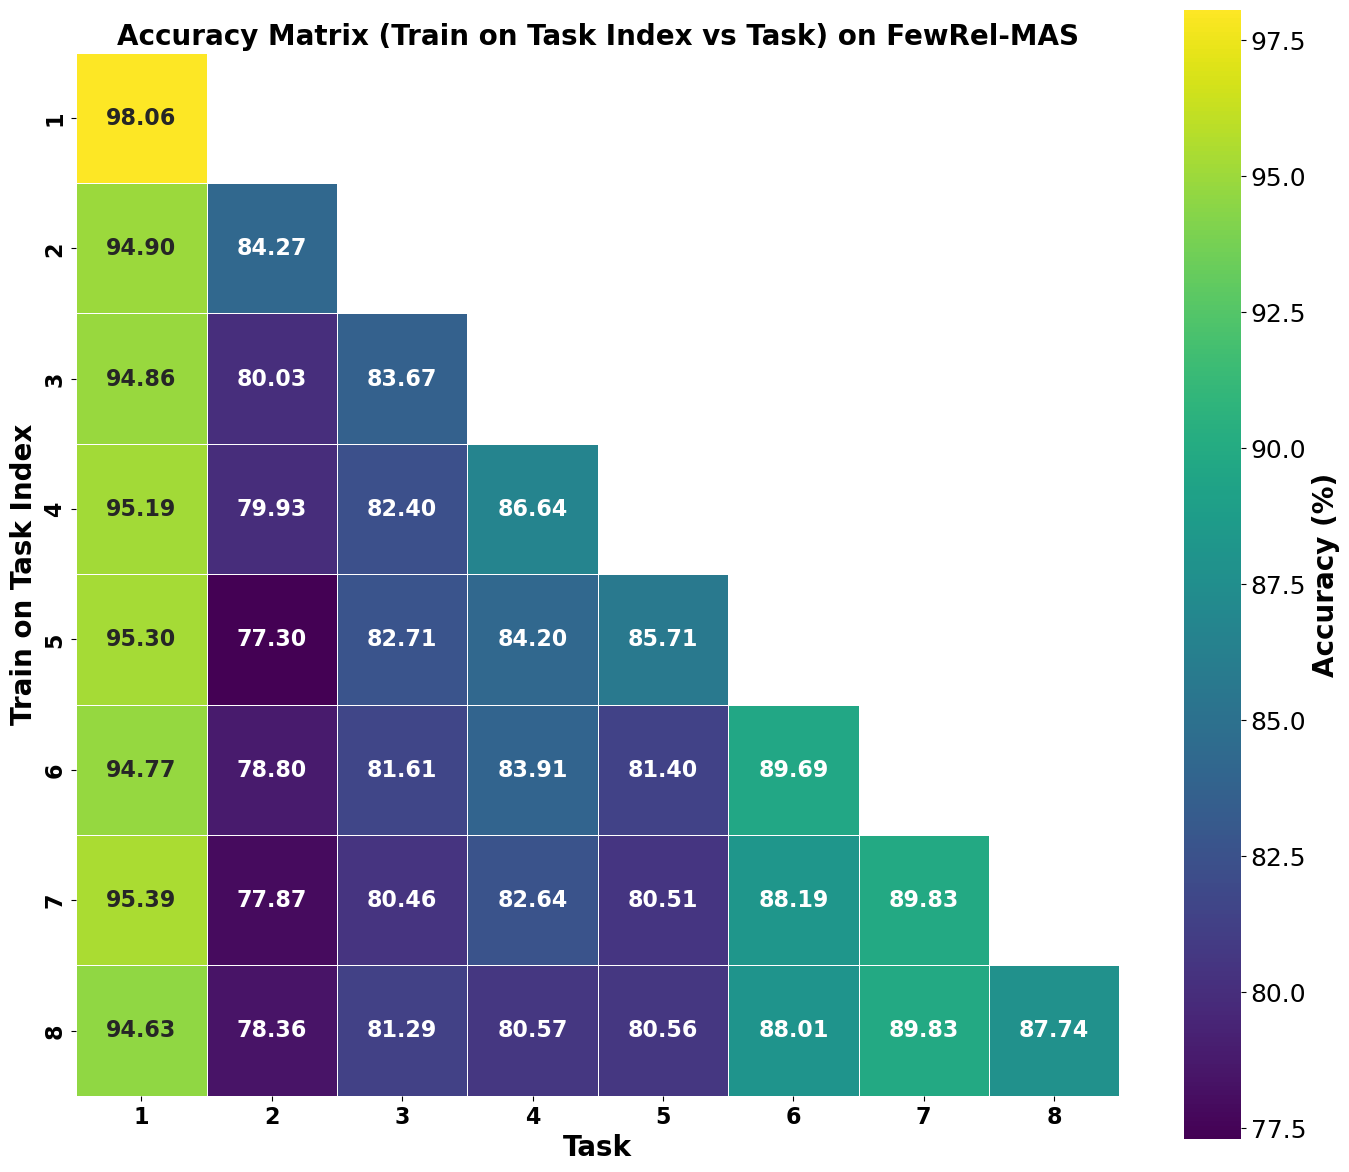

In [13]:
#tacred_t5 results-ewc

experiments = {'run_1':'/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_1_forgetting_matrix.json',
               'run_2': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_2_forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_3_forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_4_forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/mas/model_5_forgetting_matrix.json'}
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)

combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)

df_percent = df * 100  # Convert to percentage
# Update the y-axis label
# Save the heatmap with updated font sizes as a high-resolution PNG
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    df_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 16, "weight": "bold"},
    linewidths=0.5,
    square=True
)

plt.title("Accuracy Matrix (Train on Task Index vs Task) on FewRel-MAS", fontsize=20, weight="bold")
plt.xlabel("Task", fontsize=20, weight="bold")
plt.ylabel("Train on Task Index", fontsize=20, weight="bold")
plt.xticks(fontsize=16, weight="bold")
plt.yticks(fontsize=16, weight="bold")

# Adjust colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Accuracy (%)", fontsize=20, weight="bold")

# Save the figure
file_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_mas_fewrel.png"
eps_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_mas_fewrel.eps"
plt.tight_layout()
plt.savefig(file_path, dpi=350)
plt.savefig(eps_path, format='eps')
# plt.close()
plt.show()






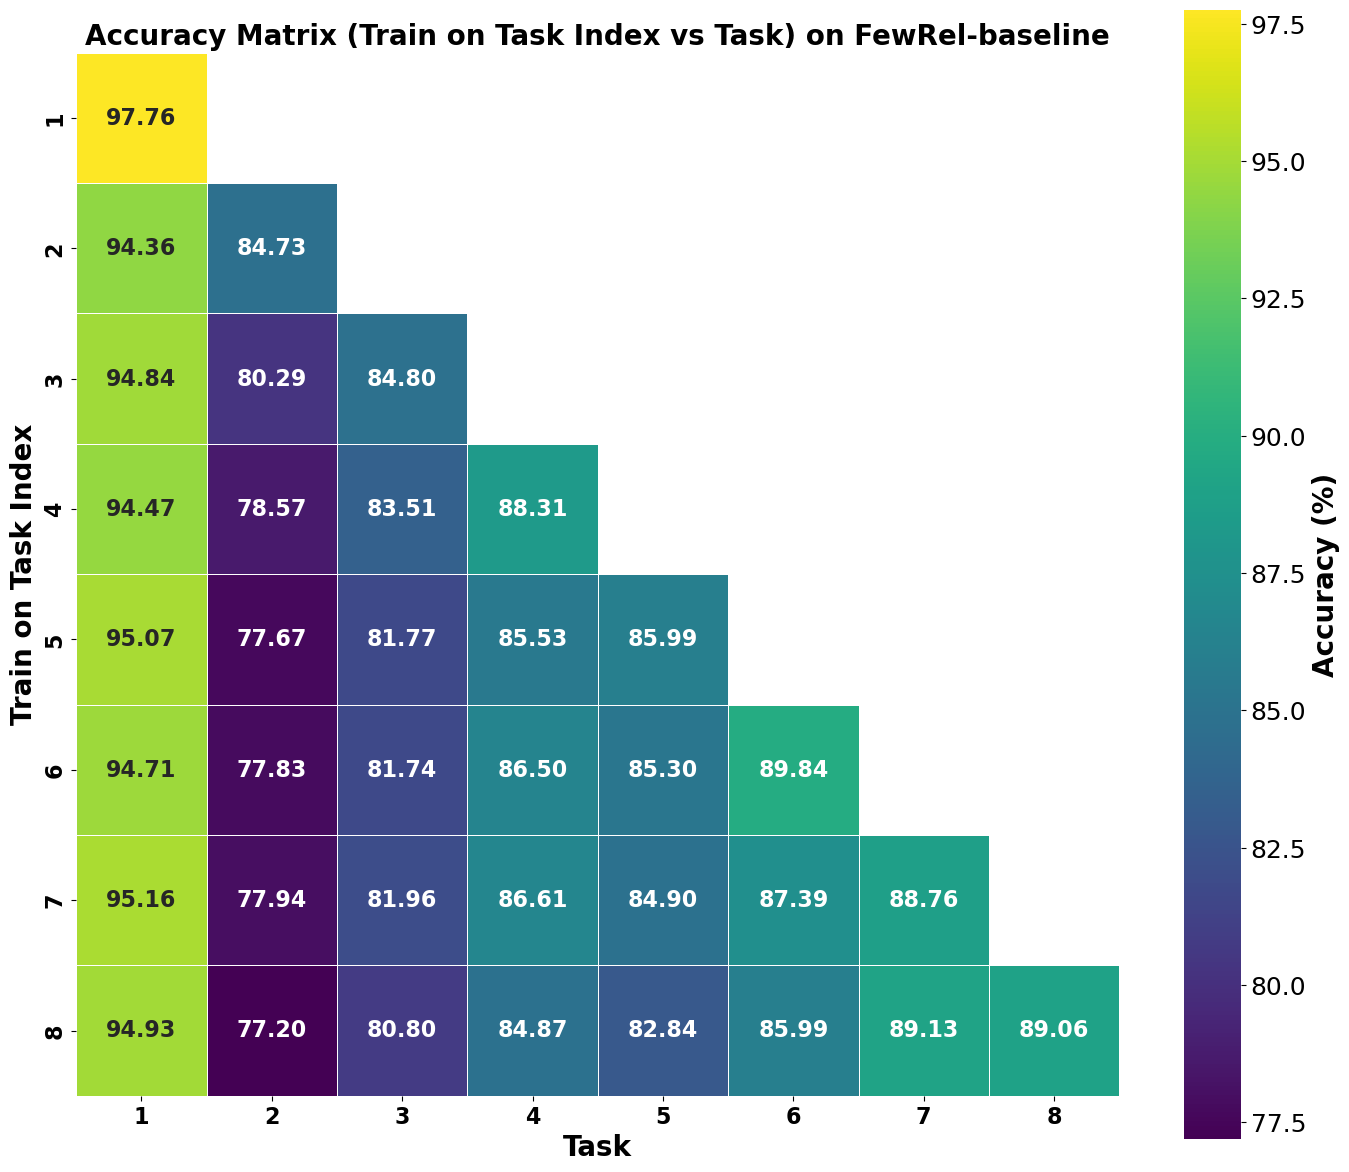

In [16]:
#tacred_t5 results-ewc

experiments = {'run_1':'/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_1_forgetting_matrix.json',
               'run_2': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_2_forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_3_forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_4_forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/llm-catastrophic-re/fewrel_corrected_results/tmlr/baseline/model_5_forgetting_matrix.json'}
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)

combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)

df_percent = df * 100  # Convert to percentage
# Update the y-axis label
# Save the heatmap with updated font sizes as a high-resolution PNG
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    df_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 16, "weight": "bold"},
    linewidths=0.5,
    square=True
)

plt.title("Accuracy Matrix (Train on Task Index vs Task) on FewRel-baseline", fontsize=20, weight="bold")
plt.xlabel("Task", fontsize=20, weight="bold")
plt.ylabel("Train on Task Index", fontsize=20, weight="bold")
plt.xticks(fontsize=16, weight="bold")
plt.yticks(fontsize=16, weight="bold")

# Adjust colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Accuracy (%)", fontsize=20, weight="bold")

# Save the figure
file_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_baseline_fewrel.png"
eps_path = "/Users/sefika/phd_projects/llm-catastrophic-re/metrics/figures/accuracy_matrix_percent_baseline_fewrel.eps"
plt.tight_layout()
plt.savefig(file_path, dpi=350)
plt.savefig(eps_path, format='eps')
# plt.close()
plt.show()




